# SRAI Book 9 Lesson 1
## AI Strategy and Transformation
**Production unit:** PU-B09-C01  
**Version:** 0.1  
This laboratory converts executive judgement into transparent, reviewable evidence. All institutional data are synthetic.

## 1 Learning objectives
Build a readiness profile, prioritize an AI portfolio, test sensitivity, define gates and produce an executive recommendation. Scores support deliberation; they do not authorize investment or deployment.

In [1]:
import sys, platform, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
SEED=42
rng=np.random.default_rng(SEED)
pd.set_option('display.max_columns',30)
print({'python':sys.version.split()[0],'platform':platform.system(),'seed':SEED})

{'python': '3.12.14', 'platform': 'Linux', 'seed': 42}


## 2 Synthetic institution
The Ministry of Evidence and Rural Services combines surveys, administrative records and regional reporting. Six proposed initiatives compete for limited delivery and governance capacity.

In [2]:
initiatives=pd.DataFrame([
['Quality anomaly triage',4.8,4.4,4.0,4.2,3.6,2.0,3.8,3.8],
['Controlled document search',4.1,3.8,4.6,4.5,4.0,1.6,4.2,4.3],
['Autonomous eligibility decisions',4.6,4.5,2.4,2.6,2.2,4.9,1.8,2.0],
['Enumerator support assistant',4.4,4.0,3.8,3.9,3.4,2.7,3.5,3.6],
['Food-loss forecasting',4.3,4.2,3.0,3.4,3.1,3.2,2.9,3.0],
['General staff chatbot',2.8,2.5,4.5,4.6,4.1,2.3,4.4,4.2]],columns=['initiative','mission','beneficiary','data','technical','capacity','risk','time_to_evidence','affordability'])
initiatives

,initiative,mission,beneficiary,data,technical,capacity,risk,time_to_evidence,affordability
0,Quality anomaly triage,4.8,4.4,4.0,4.2,3.6,2.0,3.8,3.8
1,Controlled document search,4.1,3.8,4.6,4.5,4.0,1.6,4.2,4.3
2,Autonomous eligibility decisions,4.6,4.5,2.4,2.6,2.2,4.9,1.8,2.0
3,Enumerator support assistant,4.4,4.0,3.8,3.9,3.4,2.7,3.5,3.6
4,Food-loss forecasting,4.3,4.2,3.0,3.4,3.1,3.2,2.9,3.0
5,General staff chatbot,2.8,2.5,4.5,4.6,4.1,2.3,4.4,4.2


### Data dictionary
Scores use a 1 to 5 scale. Higher is better except `risk`, where 5 means greater inherent risk. The exercise uses anchored expert judgement, not measured facts.

In [3]:
criteria=[c for c in initiatives.columns if c!='initiative']
initiatives[criteria].describe().round(2)

,mission,beneficiary,data,technical,capacity,risk,time_to_evidence,affordability
count,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00
mean,4.17,3.90,3.72,3.87,3.40,2.78,3.43,3.48
std,0.71,0.73,0.86,0.76,0.70,1.18,0.96,0.86
min,2.80,2.50,2.40,2.60,2.20,1.60,1.80,2.00
25%,4.15,3.85,3.20,3.52,3.18,2.08,3.05,3.15
50%,4.35,4.10,3.90,4.05,3.50,2.50,3.65,3.70
75%,4.55,4.35,4.38,4.42,3.90,3.08,4.10,4.10
max,4.80,4.50,4.60,4.60,4.10,4.90,4.40,4.30


## 3 Readiness profile

In [4]:
readiness=pd.DataFrame({'pillar':['Mission and value','Data and evidence','Technology and delivery','Responsible governance','People and adoption','Measurement and learning'],'score':[4.4,3.1,3.6,2.7,3.0,2.5],'confidence':[0.90,0.75,0.80,0.65,0.70,0.60],'critical_evidence':['strategic plan and service baseline','quality reports and lineage samples','architecture and support inventory','charters and risk procedures','skills inventory and training evidence','indicator definitions and benefits register']})
readiness

,pillar,score,confidence,critical_evidence
0,Mission and value,4.4,0.90,strategic plan and service baseline
1,Data and evidence,3.1,0.75,quality reports and lineage samples
2,Technology and delivery,3.6,0.80,architecture and support inventory
3,Responsible governance,2.7,0.65,charters and risk procedures
4,People and adoption,3.0,0.70,skills inventory and training evidence
5,Measurement and learning,2.5,0.60,indicator definitions and benefits register


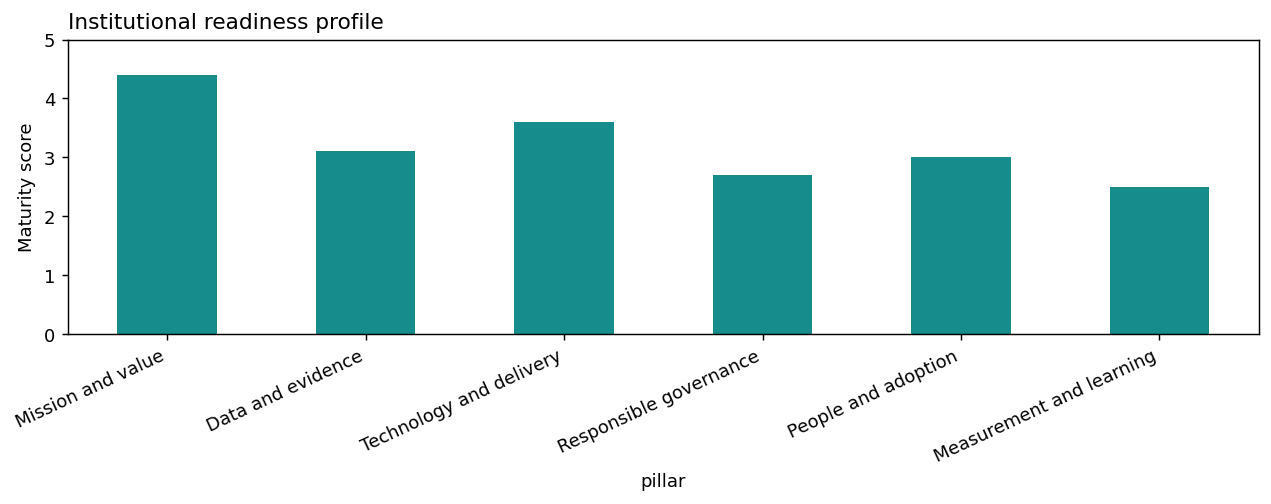

In [5]:
ax=readiness.plot.bar(x='pillar',y='score',ylim=(0,5),legend=False,color='#168C8C',figsize=(10,4)); ax.set_ylabel('Maturity score'); ax.set_title('Institutional readiness profile',loc='left'); plt.xticks(rotation=25,ha='right'); plt.tight_layout(); plt.show()

### Confidence-adjusted interpretation
Low confidence is not the same as low maturity. It signals that leadership needs stronger evidence before relying on the score.

In [6]:
readiness['confidence_adjusted']=readiness.score*readiness.confidence
readiness.sort_values('confidence_adjusted')[['pillar','score','confidence','confidence_adjusted']].round(2)

,pillar,score,confidence,confidence_adjusted
5,Measurement and learning,2.5,0.60,1.50
3,Responsible governance,2.7,0.65,1.76
4,People and adoption,3.0,0.70,2.10
1,Data and evidence,3.1,0.75,2.33
2,Technology and delivery,3.6,0.80,2.88
0,Mission and value,4.4,0.90,3.96


**Decision observation.** Measurement and governance are bottlenecks. High-consequence initiatives should not progress until their evidence actions are completed.

## 4 Strategic scoring model

In [7]:
weights={'mission':.20,'beneficiary':.12,'data':.14,'technical':.12,'capacity':.10,'risk':.16,'time_to_evidence':.08,'affordability':.08}
assert abs(sum(weights.values())-1)<1e-9
weights

{'mission': 0.2, 'beneficiary': 0.12, 'data': 0.14, 'technical': 0.12, 'capacity': 0.1, 'risk': 0.16, 'time_to_evidence': 0.08, 'affordability': 0.08}

Risk is reverse-scored. A separate non-negotiable gate will still prevent an unacceptable risk from being traded against value.

In [8]:
scored=initiatives.copy(); scored['risk_acceptability']=6-scored['risk']
score_cols={**{k:k for k in weights if k!='risk'},'risk':'risk_acceptability'}
scored['weighted_score']=sum(scored[score_cols[k]]*w for k,w in weights.items())
scored[['initiative','weighted_score']].sort_values('weighted_score',ascending=False).round(3)

,initiative,weighted_score
1,Controlled document search,4.244
0,Quality anomaly triage,4.160
3,Enumerator support assistant,3.796
5,General staff chatbot,3.732
4,Food-loss forecasting,3.422
2,Autonomous eligibility decisions,2.808


## 5 Mandatory gates

In [9]:
scored['risk_gate']=scored['risk']<=4.0
scored['data_gate']=scored['data']>=3.0
scored['capacity_gate']=scored['capacity']>=2.8
scored['eligible']=scored[['risk_gate','data_gate','capacity_gate']].all(axis=1)
scored[['initiative','weighted_score','risk_gate','data_gate','capacity_gate','eligible']].sort_values('weighted_score',ascending=False)

,initiative,weighted_score,risk_gate,data_gate,capacity_gate,eligible
1,Controlled document search,4.244,True,True,True,True
0,Quality anomaly triage,4.160,True,True,True,True
3,Enumerator support assistant,3.796,True,True,True,True
5,General staff chatbot,3.732,True,True,True,True
4,Food-loss forecasting,3.422,True,True,True,True
2,Autonomous eligibility decisions,2.808,False,False,False,False


The autonomous eligibility proposal fails mandatory gates. Its high mission value does not authorize progression.

## 6 Portfolio position

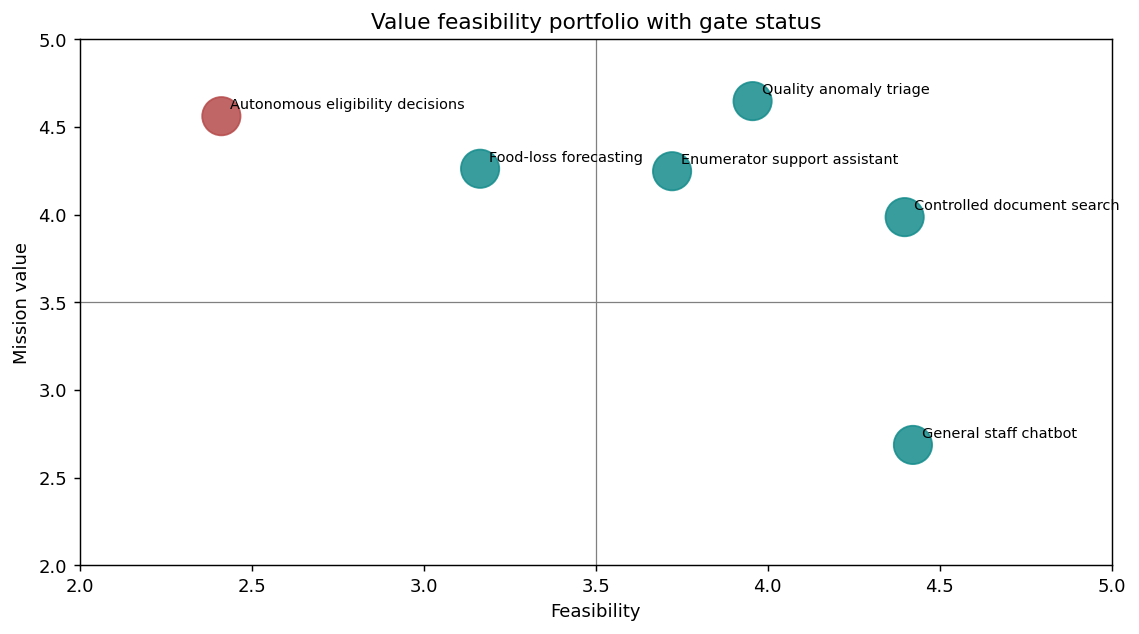

In [10]:
scored['value']=.62*scored.mission+.38*scored.beneficiary
scored['feasibility']=.38*scored.data+.34*scored.technical+.28*scored.capacity
fig,ax=plt.subplots(figsize=(9,5)); colors=np.where(scored.eligible,'#168C8C','#B64B4B'); ax.scatter(scored.feasibility,scored.value,s=450,c=colors,alpha=.85)
for _,r in scored.iterrows(): ax.annotate(r.initiative,(r.feasibility,r.value),xytext=(5,4),textcoords='offset points',fontsize=8)
ax.set(xlim=(2,5),ylim=(2,5),xlabel='Feasibility',ylabel='Mission value',title='Value feasibility portfolio with gate status'); ax.axvline(3.5,color='grey',lw=.7); ax.axhline(3.5,color='grey',lw=.7); plt.tight_layout(); plt.show()

## 7 Sensitivity analysis
We test whether plausible weight changes reverse the portfolio ranking.

In [11]:
def portfolio_score(df,w):
    z=df.copy(); z['risk_acceptability']=6-z.risk
    return sum(z[score_cols[k]]*v for k,v in w.items())
scenarios={'balanced':weights,'mission_led':{'mission':.30,'beneficiary':.15,'data':.12,'technical':.08,'capacity':.08,'risk':.15,'time_to_evidence':.06,'affordability':.06},'readiness_led':{'mission':.14,'beneficiary':.08,'data':.22,'technical':.17,'capacity':.15,'risk':.14,'time_to_evidence':.05,'affordability':.05}}
scenario_scores=pd.DataFrame({'initiative':scored.initiative,**{n:portfolio_score(scored,w) for n,w in scenarios.items()}})
scenario_scores.round(3)

,initiative,balanced,mission_led,readiness_led
0,Quality anomaly triage,4.160,4.260,4.098
1,Controlled document search,4.244,4.202,4.296
2,Autonomous eligibility decisions,2.808,3.120,2.648
3,Enumerator support assistant,3.796,3.881,3.762
4,Food-loss forecasting,3.422,3.574,3.328
5,General staff chatbot,3.732,3.522,3.927


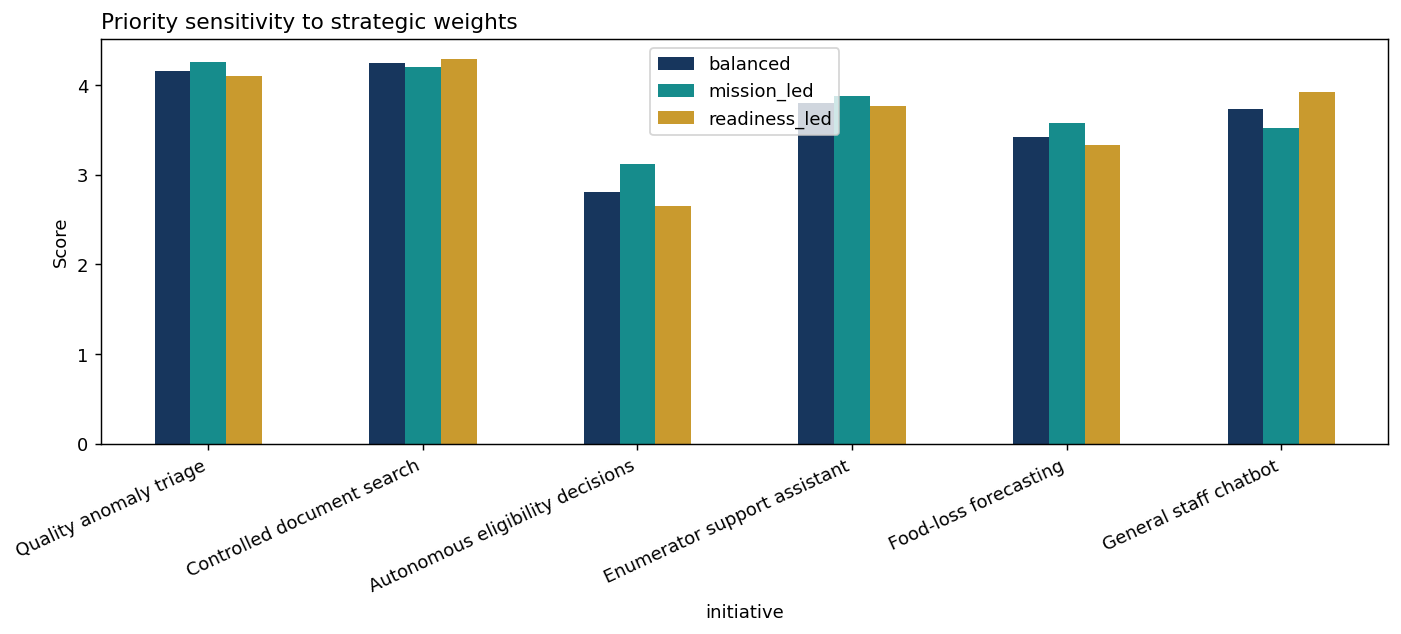

In [12]:
scenario_scores.set_index('initiative').plot.bar(figsize=(11,5),color=['#17365D','#168C8C','#C99A2E']); plt.ylabel('Score'); plt.title('Priority sensitivity to strategic weights',loc='left'); plt.xticks(rotation=25,ha='right'); plt.tight_layout(); plt.show()

## 8 Monte Carlo uncertainty

In [13]:
draws=[]
for _ in range(2000):
    noisy=scored.copy(); noisy[criteria]=np.clip(noisy[criteria]+rng.normal(0,.28,(len(noisy),len(criteria))),1,5)
    vals=portfolio_score(noisy,weights)
    draws.append(vals.to_numpy())
draws=np.array(draws)
uncertainty=pd.DataFrame({'initiative':scored.initiative,'mean':draws.mean(0),'p05':np.quantile(draws,.05,axis=0),'p95':np.quantile(draws,.95,axis=0),'top_rank_probability':(draws.argmax(1)[:,None]==np.arange(len(scored))).mean(0)})
uncertainty.sort_values('mean',ascending=False).round(3)

,initiative,mean,p05,p95,top_rank_probability
1,Controlled document search,4.242,4.076,4.410,0.746
0,Quality anomaly triage,4.151,3.986,4.316,0.254
3,Enumerator support assistant,3.792,3.620,3.960,0.000
5,General staff chatbot,3.732,3.563,3.899,0.000
4,Food-loss forecasting,3.418,3.248,3.594,0.000
2,Autonomous eligibility decisions,2.815,2.656,2.970,0.000


Intervals and top-rank probability reveal whether a priority is robust. Leadership should commission new evidence when rankings are close and consequences are material.

## 9 Dependency-aware sequencing

In [14]:
dependencies={'Quality anomaly triage':['Data quality register','Methodological review'],'Controlled document search':['Approved corpus','Access controls'],'Autonomous eligibility decisions':['Legal basis','Appeal process','Bias validation'],'Enumerator support assistant':['Approved manuals','Field escalation'],'Food-loss forecasting':['Comparable definitions','Country validation'],'General staff chatbot':['Knowledge ownership','Usage policy']}
pd.DataFrame([(k,d) for k,v in dependencies.items() for d in v],columns=['initiative','dependency'])

,initiative,dependency
0,Quality anomaly triage,Data quality register
1,Quality anomaly triage,Methodological review
2,Controlled document search,Approved corpus
3,Controlled document search,Access controls
4,Autonomous eligibility decisions,Legal basis
5,Autonomous eligibility decisions,Appeal process
6,Autonomous eligibility decisions,Bias validation
7,Enumerator support assistant,Approved manuals
8,Enumerator support assistant,Field escalation
9,Food-loss forecasting,Comparable definitions


In [15]:
classification=np.select([(~scored.eligible),(scored.value>=4)&(scored.feasibility>=3.6),(scored.value>=4),(scored.feasibility>=4)],['defer or prohibit','quick evidence','strategic bet','enabler'],default='lower priority')
scored['portfolio_class']=classification
scored[['initiative','eligible','portfolio_class','weighted_score']].sort_values('weighted_score',ascending=False)

,initiative,eligible,portfolio_class,weighted_score
1,Controlled document search,True,enabler,4.244
0,Quality anomaly triage,True,quick evidence,4.160
3,Enumerator support assistant,True,quick evidence,3.796
5,General staff chatbot,True,enabler,3.732
4,Food-loss forecasting,True,strategic bet,3.422
2,Autonomous eligibility decisions,False,defer or prohibit,2.808


## 10 Roadmap and gates

In [16]:
roadmap=pd.DataFrame([['Mobilize','0-3','Validate mandate, owners and baseline','Executive sponsor'],['Qualify','3-6','Data tests, risk map and comparator','Steering committee'],['Pilot','6-12','Operational evaluation and user evidence','Benefit owner'],['Institutionalize','12-18','Support, budget, controls and training','Service owner'],['Review','18-24','Benefits, incidents and sustainability','Executive board']],columns=['phase','months','evidence','decision_owner'])
roadmap

,phase,months,evidence,decision_owner
0,Mobilize,0-3,"Validate mandate, owners and baseline",Executive sponsor
1,Qualify,3-6,"Data tests, risk map and comparator",Steering committee
2,Pilot,6-12,Operational evaluation and user evidence,Benefit owner
3,Institutionalize,12-18,"Support, budget, controls and training",Service owner
4,Review,18-24,"Benefits, incidents and sustainability",Executive board


In [17]:
gates=pd.DataFrame([['G1 Problem','Baseline, beneficiary, non-AI comparator','Proceed to design'],['G2 Data','Quality, lineage, access, representativeness','Authorize data use'],['G3 Risk','Risk map, controls, recourse','Accept bounded pilot risk'],['G4 Pilot','Comparator, outcomes, incidents, adoption','Scale, redesign or stop'],['G5 Scale','Service ownership, budget, monitoring','Authorize production']],columns=['gate','minimum_evidence','decision'])
gates

,gate,minimum_evidence,decision
0,G1 Problem,"Baseline, beneficiary, non-AI comparator",Proceed to design
1,G2 Data,"Quality, lineage, access, representativeness",Authorize data use
2,G3 Risk,"Risk map, controls, recourse",Accept bounded pilot risk
3,G4 Pilot,"Comparator, outcomes, incidents, adoption","Scale, redesign or stop"
4,G5 Scale,"Service ownership, budget, monitoring",Authorize production


## 11 Governance register

In [18]:
governance=pd.DataFrame([['Executive sponsor','Authorize strategy and resources','Portfolio decision record'],['Benefit owner','Own baseline, adoption and value','Benefits review'],['Domain owner','Protect professional validity','Method approval'],['Data owner and steward','Govern purpose, access and quality','Data qualification'],['Technical owner','Build, test, operate and monitor','Technical evidence pack'],['Risk and assurance','Challenge controls and escalate','Independent review']],columns=['role','accountability','evidence_product'])
governance

,role,accountability,evidence_product
0,Executive sponsor,Authorize strategy and resources,Portfolio decision record
1,Benefit owner,"Own baseline, adoption and value",Benefits review
2,Domain owner,Protect professional validity,Method approval
3,Data owner and steward,"Govern purpose, access and quality",Data qualification
4,Technical owner,"Build, test, operate and monitor",Technical evidence pack
5,Risk and assurance,Challenge controls and escalate,Independent review


## 12 Executive dashboard

In [19]:
dashboard=scored.merge(uncertainty,on='initiative').loc[:,['initiative','weighted_score','eligible','portfolio_class','p05','p95','top_rank_probability']]
dashboard.sort_values(['eligible','weighted_score'],ascending=False).round(3)

,initiative,weighted_score,eligible,portfolio_class,p05,p95,top_rank_probability
1,Controlled document search,4.244,True,enabler,4.076,4.410,0.746
0,Quality anomaly triage,4.160,True,quick evidence,3.986,4.316,0.254
3,Enumerator support assistant,3.796,True,quick evidence,3.620,3.960,0.000
5,General staff chatbot,3.732,True,enabler,3.563,3.899,0.000
4,Food-loss forecasting,3.422,True,strategic bet,3.248,3.594,0.000
2,Autonomous eligibility decisions,2.808,False,defer or prohibit,2.656,2.970,0.000


In [20]:
recommended=dashboard.query('eligible').sort_values('weighted_score',ascending=False).iloc[0]
print(f"Recommended controlled pilot: {recommended.initiative}")
print(f"Score: {recommended.weighted_score:.2f}; uncertainty interval: {recommended.p05:.2f}-{recommended.p95:.2f}")
print('Authorization remains conditional on G1-G3 evidence and a named benefit owner.')

Recommended controlled pilot: Controlled document search
Score: 4.24; uncertainty interval: 4.08-4.41
Authorization remains conditional on G1-G3 evidence and a named benefit owner.


## 13 Exercises
1. Change the risk threshold from 4.0 to 3.0. Which initiatives remain eligible?  
2. Create an equity criterion and justify its weight.  
3. Increase uncertainty for data readiness and interpret the ranking stability.  
4. Draft a stop condition for the recommended pilot.

In [21]:
# Exercise 1 solution
strict_risk=scored.assign(strict_risk_gate=scored.risk<=3.0)
strict_risk[['initiative','risk','strict_risk_gate']]

,initiative,risk,strict_risk_gate
0,Quality anomaly triage,2.0,True
1,Controlled document search,1.6,True
2,Autonomous eligibility decisions,4.9,False
3,Enumerator support assistant,2.7,True
4,Food-loss forecasting,3.2,False
5,General staff chatbot,2.3,True


### Exercise guidance
A strong equity criterion has an operational definition, relevant disaggregation, evidence source and decision consequence. A strong stop condition specifies a measurable threshold, observation window, responsible monitor and required action.

## 14 Export controlled evidence

In [22]:
out=Path('notebook_outputs'); out.mkdir(exist_ok=True)
readiness.to_csv(out/'readiness_profile.csv',index=False)
dashboard.to_csv(out/'portfolio_dashboard.csv',index=False)
roadmap.to_csv(out/'transformation_roadmap.csv',index=False)
with open(out/'decision_record.json','w') as f: json.dump({'production_unit':'PU-B09-C01','recommended_pilot':recommended.initiative,'condition':'Pass G1-G3 and name benefit owner','seed':SEED},f,indent=2)
sorted(str(p) for p in out.iterdir())

['notebook_outputs/decision_record.json', 'notebook_outputs/portfolio_dashboard.csv', 'notebook_outputs/readiness_profile.csv', 'notebook_outputs/transformation_roadmap.csv']

## 15 Closing insight
A reproducible score is valuable because it makes assumptions visible. It is not an automatic authorization. Executives remain accountable for interpreting evidence, uncertainty, rights, institutional capacity and opportunity cost.